# Spring-to-Summer Transition of PM2.5 Across Major Chinese Cities (2021 H1)

**Final Project: Computing and Research Methods for Climate Data Science**  
Student: Wenzhuo Tian  
wt2394

This notebook investigates how fine particulate matter (PM2.5) changes from late winter through summer in four major Chinese cities: Shanghai, Chengdu, Guangzhou, and Shenyang, and whether these cities show different seasonal, transition strength, and diurnal pollution patterns. Hourly observations are sourced from real ground-based monitoring stations via the OpenAQ API.

## Research question and testable hypotheses

**Research question:**  
How do PM2.5 concentrations change from late winter (January-February) through summer (June-August) in four major Chinese cities, and do these cities show distinct seasonal-transition strengths and diurnal pollution patterns?

**Hypothesis 1, seasonal-transition contrast:**  
Cities in northern or inland settings (Shenyang and Chengdu) will show a larger late-winter-to-summer PM2.5 drop than coastal/southern cities (Shanghai and Guangzhou). The reasoning: northern China's residual heating-season emissions and stable winter boundary layers produce strong January-February peaks, which decay sharply as solar heating deepens the boundary layer in spring and summer; coastal/southern cities benefit from year-round marine ventilation and weaker heating signals, so their seasonal swings should be smaller.

**Hypothesis 2, diurnal contrast:**  
Across cities, PM2.5 will be elevated during commuting-related morning and evening hours compared with midday hours, due to the combination of traffic emissions and a shallow nocturnal/early-morning boundary layer.

These hypotheses are testable because the notebook computes period means (Late Winter / Spring / Summer), winter-minus-summer differences, hourly diurnal profiles, and simple statistical comparisons from time-stamped PM2.5 data.

## Data source and reproducibility plan

This project uses **OpenAQ v3 API** to retrieve hourly ground-based PM2.5 observations from real monitoring stations in each city. An `OPENAQ_API_KEY` environment variable is required. The notebook also includes an Open-Meteo Air Quality API fallback (CAMS-modeled values) for any city where OpenAQ data is unavailable, but in this run all four cities are successfully covered by OpenAQ.

**Study window:** January 1 to August 9, 2021. This window was chosen because OpenAQ's upstream Chinese data provider stopped pushing real-time data after early August 2021, and using the truncated common window keeps all four cities directly comparable. This means the analysis covers late winter, spring, and summer, but not autumn or full winter.

**Cities and station coordinates:**

| City | Latitude | Longitude | OpenAQ station name | Sensor ID | Rationale |
|---|---:|---:|---|---:|---|
| Shanghai | 31.2304 | 121.4737 | 十五厂 | 31791 | Coastal, eastern China |
| Chengdu | 30.5728 | 104.0668 | 三瓦窑 | 30650 | Inland basin city |
| Guangzhou | 23.1291 | 113.2644 | 市监测站 | 34005 | Southern coastal/near-coastal |
| Shenyang | 41.8057 | 123.4315 | Shenyang | 25736 | Northern industrial city |

All data are downloaded inside the notebook via Python `requests` calls to the OpenAQ v3 `/sensors/{id}/hours` endpoint, queried month-by-month to avoid server timeouts. The final analysis uses Pandas for cleaning, aggregation, grouping, hypothesis testing, and visualization.

## 1. Set up Python environment

In [1]:
import os
import time
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)

In [21]:
import os
if os.getenv("OPENAQ_API_KEY"):
    print("OpenAQ API key detected in environment.")
else:
    print("WARNING: OPENAQ_API_KEY is not set; OpenAQ calls will fail and "
          "loaders will fall back to Open-Meteo. See README.md for setup.")

OpenAQ API key detected in environment.


## 2. Define study settings

The analysis uses 2021-01-01 through 2021-08-09. This window covers late winter, spring, and summer 2021 and is the maximum range over which all four cities have OpenAQ station coverage. The cutoff date reflects when the upstream Chinese data provider stopped pushing data to OpenAQ; using a common cutoff keeps the four cities directly comparable.

In [3]:
START_DATE = "2021-01-01"
END_DATE = "2021-08-09"
TIMEZONE = "Asia/Shanghai"

CITIES = {
    "Shanghai": {"lat": 31.2304, "lon": 121.4737, "region_type": "coastal/eastern"},
    "Chengdu": {"lat": 30.5728, "lon": 104.0668, "region_type": "inland/basin"},
    "Guangzhou": {"lat": 23.1291, "lon": 113.2644, "region_type": "southern"},
    "Shenyang": {"lat": 41.8057, "lon": 123.4315, "region_type": "northern/industrial"},
}

for city, meta in CITIES.items():
    print(f"{city:10s}: lat={meta['lat']:.4f}, lon={meta['lon']:.4f}, type={meta['region_type']}")

Shanghai  : lat=31.2304, lon=121.4737, type=coastal/eastern
Chengdu   : lat=30.5728, lon=104.0668, type=inland/basin
Guangzhou : lat=23.1291, lon=113.2644, type=southern
Shenyang  : lat=41.8057, lon=123.4315, type=northern/industrial


## 3. Data loading functions

The functions below try OpenAQ first when an API key is present. If no key is found, the notebook automatically uses Open-Meteo. Both routes return the same tidy format:

`city`, `datetime`, `pm25`, `source`, `lat`, `lon`

In [4]:
import calendar
from datetime import date


def _request_json(url, params=None, headers=None, pause=0.15, timeout=60):
    """Small helper for API requests with readable errors."""
    r = requests.get(url, params=params, headers=headers, timeout=timeout)
    if r.status_code >= 400:
        raise RuntimeError(f"Request failed ({r.status_code}): {r.url}\n{r.text[:500]}")
    time.sleep(pause)
    return r.json()


def _to_iso_utc(date_str):
    return f"{date_str}T00:00:00Z"


def _haversine_km(lat1, lon1, lat2, lon2):
    import math
    R = 6371.0
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dp = math.radians(lat2 - lat1)
    dl = math.radians(lon2 - lon1)
    a = math.sin(dp / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dl / 2) ** 2
    return 2 * R * math.asin(math.sqrt(a))


def _month_chunks(start_date, end_date):
    """Split [start_date, end_date] into month-long chunks, inclusive on both ends."""
    sy, sm, sd = (int(x) for x in start_date.split("-"))
    ey, em, ed = (int(x) for x in end_date.split("-"))
    cur_y, cur_m = sy, sm
    while (cur_y, cur_m) <= (ey, em):
        chunk_first = date(cur_y, cur_m, 1)
        if (cur_y, cur_m) == (sy, sm):
            chunk_first = date(sy, sm, sd)
        last_dom = calendar.monthrange(cur_y, cur_m)[1]
        chunk_last = date(cur_y, cur_m, last_dom)
        if (cur_y, cur_m) == (ey, em):
            chunk_last = date(ey, em, ed)
        yield chunk_first.isoformat(), chunk_last.isoformat()
        if cur_m == 12:
            cur_y, cur_m = cur_y + 1, 1
        else:
            cur_m += 1


def load_city_open_meteo(city, lat, lon, start_date=START_DATE, end_date=END_DATE):
    """Load hourly PM2.5 from Open-Meteo Air Quality API for one city."""
    url = "https://air-quality-api.open-meteo.com/v1/air-quality"
    params = {
        "latitude": lat,
        "longitude": lon,
        "hourly": "pm2_5",
        "start_date": start_date,
        "end_date": end_date,
        "timezone": TIMEZONE,
    }
    js = _request_json(url, params=params)
    hourly = js.get("hourly", {})
    if "time" not in hourly or "pm2_5" not in hourly:
        raise ValueError(f"Open-Meteo response did not contain expected hourly PM2.5 for {city}.")
    df = pd.DataFrame({
        "datetime": pd.to_datetime(hourly["time"]),
        "pm25": pd.to_numeric(hourly["pm2_5"], errors="coerce"),
    })
    df["city"] = city
    df["lat"] = lat
    df["lon"] = lon
    df["source"] = "Open-Meteo Air Quality API (CAMS-modeled)"
    return df


def _find_pm25_sensor(location, headers):
    for s in location.get("sensors", []) or []:
        param = s.get("parameter", {}) or {}
        if param.get("id") == 2 or str(param.get("name", "")).lower().startswith("pm2"):
            return s.get("id")
    lid = location.get("id")
    if lid is None:
        return None
    url = f"https://api.openaq.org/v3/locations/{lid}/sensors"
    js = _request_json(url, headers=headers)
    for s in js.get("results", []) or []:
        param = s.get("parameter", {}) or {}
        if param.get("id") == 2 or str(param.get("name", "")).lower().startswith("pm2"):
            return s.get("id")
    return None


def _pick_nearest_pm25_location(city_lat, city_lon, locations, headers):
    def dist(loc):
        c = loc.get("coordinates") or {}
        clat, clon = c.get("latitude"), c.get("longitude")
        if clat is None or clon is None:
            return float("inf")
        return _haversine_km(city_lat, city_lon, clat, clon)
    for loc in sorted(locations, key=dist):
        sid = _find_pm25_sensor(loc, headers)
        if sid is not None:
            return loc, sid
    return None, None


def _fetch_hours_for_chunk(sensor_id, chunk_start, chunk_end, headers):
    """Fetch all hourly rows for a single time chunk, paginated."""
    hours_url = f"https://api.openaq.org/v3/sensors/{sensor_id}/hours"
    rows = []
    page = 1
    limit = 1000
    while page <= 50:
        params = {
            "datetime_from": _to_iso_utc(chunk_start),
            "datetime_to": _to_iso_utc(chunk_end),
            "limit": limit,
            "page": page,
        }
        page_js = _request_json(hours_url, params=params, headers=headers)
        batch = page_js.get("results", []) or []
        if not batch:
            break
        rows.extend(batch)
        if len(batch) < limit:
            break
        page += 1
    return rows


def load_city_openaq(city, lat, lon, start_date=START_DATE, end_date=END_DATE,
                     search_radius_m=25000):
    """Hourly PM2.5 from OpenAQ v3, queried month-by-month."""
    api_key = os.getenv("OPENAQ_API_KEY")
    if not api_key:
        raise RuntimeError("OPENAQ_API_KEY not found in environment.")
    headers = {"X-API-Key": api_key}

    # 1. Locate nearest PM2.5 station
    locations_url = "https://api.openaq.org/v3/locations"
    locations_params = {
        "coordinates": f"{lat},{lon}",
        "radius": search_radius_m,
        "parameters_id": 2,
        "limit": 100,
    }
    js = _request_json(locations_url, params=locations_params, headers=headers)
    candidates = js.get("results", []) or []
    if not candidates:
        raise RuntimeError(f"No OpenAQ PM2.5 stations within {search_radius_m/1000:.0f} km of {city}.")
    chosen_loc, sensor_id = _pick_nearest_pm25_location(lat, lon, candidates, headers)
    if sensor_id is None:
        raise RuntimeError(f"Found {len(candidates)} stations near {city}, but none expose a PM2.5 sensor.")

    # 2. Pull hourly data month-by-month; skip months that timeout individually.
    all_rows = []
    skipped = []
    chunks = list(_month_chunks(start_date, end_date))
    for i, (chunk_start, chunk_end) in enumerate(chunks, 1):
        try:
            rows = _fetch_hours_for_chunk(sensor_id, chunk_start, chunk_end, headers)
            all_rows.extend(rows)
        except RuntimeError as e:
            skipped.append(chunk_start[:7])

    if not all_rows:
        raise RuntimeError(f"No OpenAQ hourly data returned for {city} (sensor {sensor_id}).")

    # 3. Tidy frame
    records = []
    for row in all_rows:
        period = row.get("period") or {}
        dt_from = period.get("datetimeFrom") or {}
        dt_utc = dt_from.get("utc") or dt_from.get("local")
        records.append({"datetime": dt_utc, "pm25": row.get("value")})

    df = pd.DataFrame(records)
    df["datetime"] = (
        pd.to_datetime(df["datetime"], errors="coerce", utc=True)
          .dt.tz_convert(TIMEZONE)
          .dt.tz_localize(None)
    )
    df["pm25"] = pd.to_numeric(df["pm25"], errors="coerce")
    df = (df.dropna(subset=["datetime", "pm25"])
            .drop_duplicates("datetime")
            .sort_values("datetime"))
    df["city"] = city
    df["lat"] = lat
    df["lon"] = lon
    df["source"] = "OpenAQ v3 API (/hours, monthly)"
    df["openaq_location_id"] = chosen_loc.get("id")
    df["openaq_location_name"] = chosen_loc.get("name")
    df["openaq_sensor_id"] = sensor_id
    if skipped:
        print(f"    (note: {city} skipped months due to timeout: {skipped})")
    return df.reset_index(drop=True)


def load_city_pm25(city, meta):
    """Try OpenAQ first; fall back to Open-Meteo if unavailable."""
    lat, lon = meta["lat"], meta["lon"]
    try:
        df = load_city_openaq(city, lat, lon)
        print(f"  {city}: loaded {len(df):,} hourly rows from OpenAQ "
              f"(station: {df['openaq_location_name'].iloc[0]}, "
              f"sensor {df['openaq_sensor_id'].iloc[0]})")
        return df
    except Exception as e:
        print(f"  {city}: OpenAQ unavailable ({e}). Falling back to Open-Meteo.")
        return load_city_open_meteo(city, lat, lon)

## 4. Load PM2.5 data

In [5]:
frames = []
for city, meta in CITIES.items():
    print(f"Loading {city}...")
    frames.append(load_city_pm25(city, meta))

raw = pd.concat(frames, ignore_index=True)
raw.head()

Loading Shanghai...
  Shanghai: loaded 3,364 hourly rows from OpenAQ (station: 十五厂, sensor 31791)
Loading Chengdu...
  Chengdu: loaded 3,434 hourly rows from OpenAQ (station: 三瓦窑, sensor 30650)
Loading Guangzhou...
  Guangzhou: loaded 3,439 hourly rows from OpenAQ (station: 市监测站, sensor 34005)
Loading Shenyang...
  Shenyang: loaded 926 hourly rows from OpenAQ (station: Shenyang, sensor 25736)


,datetime,pm25,city,lat,lon,source,openaq_location_id,openaq_location_name,openaq_sensor_id
0,2021-01-01 08:00:00,42.0,Shanghai,31.2304,121.4737,"OpenAQ v3 API (/hours, monthly)",9990,十五厂,31791
1,2021-01-01 09:00:00,43.0,Shanghai,31.2304,121.4737,"OpenAQ v3 API (/hours, monthly)",9990,十五厂,31791
2,2021-01-01 10:00:00,39.0,Shanghai,31.2304,121.4737,"OpenAQ v3 API (/hours, monthly)",9990,十五厂,31791
3,2021-01-01 11:00:00,37.0,Shanghai,31.2304,121.4737,"OpenAQ v3 API (/hours, monthly)",9990,十五厂,31791
4,2021-01-01 12:00:00,33.0,Shanghai,31.2304,121.4737,"OpenAQ v3 API (/hours, monthly)",9990,十五厂,31791


## 5. Clean and enrich the data

In [6]:
def assign_season(month):
    """Period definition for the 2021 H1 study window (Jan-Aug).
    
    'Late Winter' = Jan-Feb (heating season tail, cold + low boundary layer)
    'Spring' = Mar-May (warming, transition)
    'Summer' = Jun-Aug (warm, wet, high mixing depth)
    """
    if month in [1, 2]:
        return "Late Winter"
    if month in [3, 4, 5]:
        return "Spring"
    if month in [6, 7, 8]:
        return "Summer"
    return "Other"


def assign_day_period(hour):
    if 7 <= hour <= 10:
        return "Morning commute"
    if 12 <= hour <= 15:
        return "Midday"
    if 17 <= hour <= 21:
        return "Evening commute"
    return "Other"

pm = raw.copy()
pm["datetime"] = pd.to_datetime(pm["datetime"], errors="coerce")
pm = pm.dropna(subset=["datetime", "pm25"])
pm = pm[(pm["pm25"] >= 0) & (pm["pm25"] <= 1000)].copy()
pm = pm.sort_values(["city", "datetime"])
pm["date"] = pm["datetime"].dt.date
pm["month"] = pm["datetime"].dt.month
pm["month_name"] = pm["datetime"].dt.month_name().str[:3]
pm["season"] = pm["month"].apply(assign_season)
pm["hour"] = pm["datetime"].dt.hour
pm["day_period"] = pm["hour"].apply(assign_day_period)
pm["region_type"] = pm["city"].map({k: v["region_type"] for k, v in CITIES.items()})

season_order = ["Late Winter", "Spring", "Summer"]
pm["season"] = pd.Categorical(pm["season"], categories=season_order, ordered=True)

print(pm.shape)
pm.head()

(11163, 16)


,datetime,pm25,city,lat,lon,source,openaq_location_id,openaq_location_name,openaq_sensor_id,date,month,month_name,season,hour,day_period,region_type
3364,2021-01-01 08:00:00,67.0,Chengdu,30.5728,104.0668,"OpenAQ v3 API (/hours, monthly)",9803,三瓦窑,30650,2021-01-01,1,Jan,Late Winter,8,Morning commute,inland/basin
3365,2021-01-01 09:00:00,68.0,Chengdu,30.5728,104.0668,"OpenAQ v3 API (/hours, monthly)",9803,三瓦窑,30650,2021-01-01,1,Jan,Late Winter,9,Morning commute,inland/basin
3366,2021-01-01 10:00:00,90.0,Chengdu,30.5728,104.0668,"OpenAQ v3 API (/hours, monthly)",9803,三瓦窑,30650,2021-01-01,1,Jan,Late Winter,10,Morning commute,inland/basin
3367,2021-01-01 11:00:00,98.0,Chengdu,30.5728,104.0668,"OpenAQ v3 API (/hours, monthly)",9803,三瓦窑,30650,2021-01-01,1,Jan,Late Winter,11,Other,inland/basin
3368,2021-01-01 12:00:00,68.0,Chengdu,30.5728,104.0668,"OpenAQ v3 API (/hours, monthly)",9803,三瓦窑,30650,2021-01-01,1,Jan,Late Winter,12,Midday,inland/basin


## 6. Data coverage summary

In [8]:
coverage = (pm.groupby(["city", "source"])
              .agg(n_obs=("pm25", "size"),
                   start=("datetime", "min"),
                   end=("datetime", "max"),
                   mean_pm25=("pm25", "mean"))
              .reset_index())
coverage

,city,source,n_obs,start,end,mean_pm25
0,Chengdu,"OpenAQ v3 API (/hours, monthly)",3434,2021-01-01 08:00:00,2021-08-08 15:00:00,47.462434
1,Guangzhou,"OpenAQ v3 API (/hours, monthly)",3439,2021-01-03 12:00:00,2021-08-08 15:00:00,29.791509
2,Shanghai,"OpenAQ v3 API (/hours, monthly)",3364,2021-01-01 08:00:00,2021-08-08 15:00:00,31.138228
3,Shenyang,"OpenAQ v3 API (/hours, monthly)",926,2021-01-01 08:00:00,2021-02-24 07:00:00,65.071274


### Figure 1. Spatial setup and data coverage

This figure shows the city locations used in the analysis and the number of valid PM2.5 observations retained for each city.

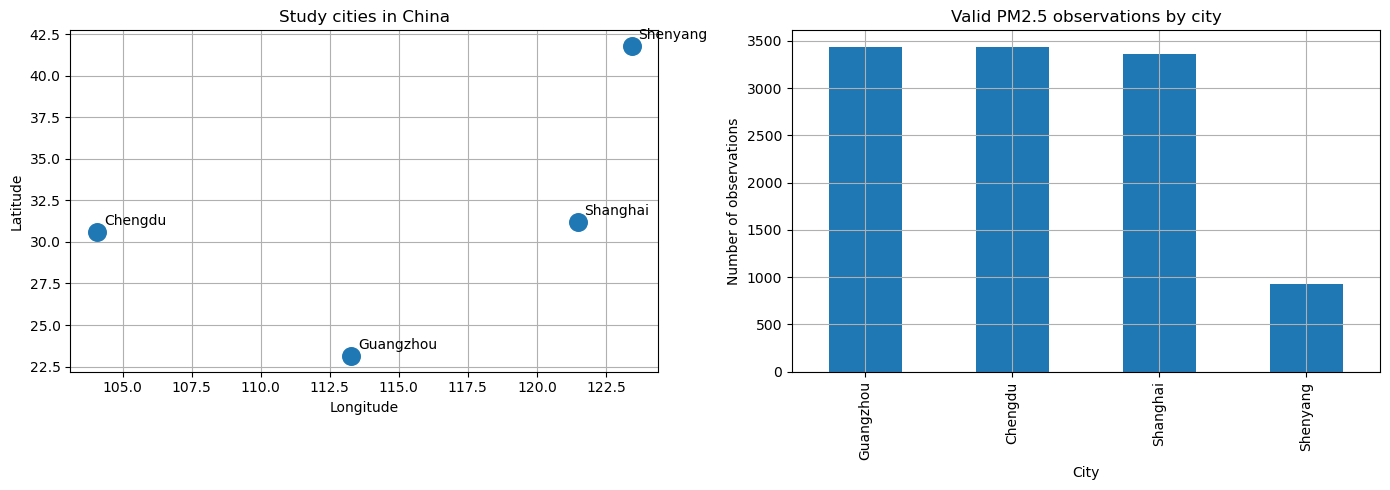

In [10]:
fig, axes = plt.subplots(ncols=2, figsize=(14, 5))

city_meta = pd.DataFrame([
    {"city": c, "lat": m["lat"], "lon": m["lon"], "region_type": m["region_type"]}
    for c, m in CITIES.items()
])
axes[0].scatter(city_meta["lon"], city_meta["lat"], s=160)
for _, row in city_meta.iterrows():
    axes[0].annotate(row["city"], (row["lon"], row["lat"]), xytext=(5, 5), textcoords="offset points")
axes[0].set_title("Study cities in China")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

coverage_by_city = coverage.groupby("city")["n_obs"].sum().sort_values(ascending=False)
coverage_by_city.plot(kind="bar", ax=axes[1])
axes[1].set_title("Valid PM2.5 observations by city")
axes[1].set_xlabel("City")
axes[1].set_ylabel("Number of observations")
plt.tight_layout()

## 7. Daily PM2.5 time series

Hourly data can be noisy, so the next figure uses daily means. This makes seasonal-scale changes easier to see.

In [11]:
daily = (pm.set_index("datetime")
           .groupby("city")
           .resample("D")["pm25"]
           .mean()
           .reset_index())
daily["month"] = daily["datetime"].dt.month
daily["season"] = pd.Categorical(daily["month"].apply(assign_season), categories=season_order, ordered=True)
daily.head()

,city,datetime,pm25,month,season
0,Chengdu,2021-01-01,73.933333,1,Late Winter
1,Chengdu,2021-01-02,79.375000,1,Late Winter
2,Chengdu,2021-01-03,82.250000,1,Late Winter
3,Chengdu,2021-01-04,115.250000,1,Late Winter
4,Chengdu,2021-01-05,99.000000,1,Late Winter


### Figure 2. Daily mean PM2.5 time series

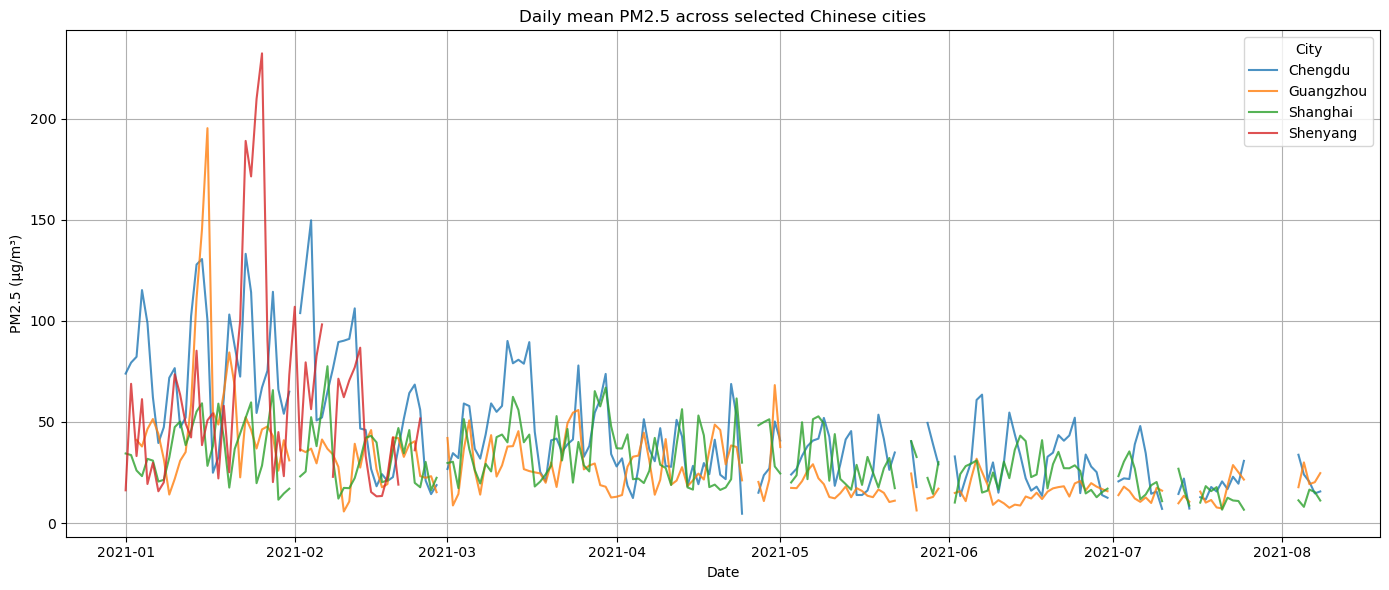

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))
for city, sub in daily.groupby("city"):
    ax.plot(sub["datetime"], sub["pm25"], label=city, alpha=0.8)
ax.set_title("Daily mean PM2.5 across selected Chinese cities")
ax.set_xlabel("Date")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.legend(title="City")
plt.tight_layout()

## 8. Seasonal patterns

To test Hypothesis 1, I compare monthly and seasonal PM2.5 means across cities. A stronger winter-to-summer gap indicates stronger seasonal contrast.

### Figure 3. Monthly PM2.5 means by city

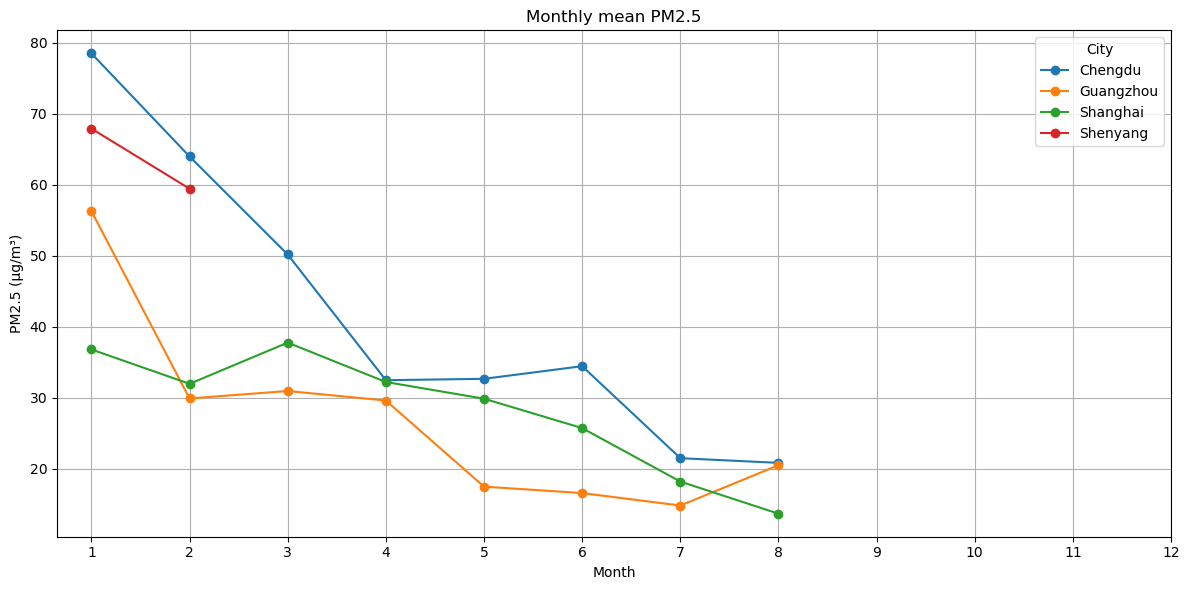

In [13]:
monthly = (pm.groupby(["city", "month"])["pm25"]
             .agg(["mean", "median", "count"])
             .reset_index())

fig, ax = plt.subplots(figsize=(12, 6))
for city, sub in monthly.groupby("city"):
    ax.plot(sub["month"], sub["mean"], marker="o", label=city)
ax.set_title("Monthly mean PM2.5")
ax.set_xlabel("Month")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_xticks(range(1, 13))
ax.legend(title="City")
plt.tight_layout()

### Figure 4. Seasonal PM2.5 distributions

Boxplots show both the central tendency and spread of PM2.5 by season. This helps reveal whether seasonal differences are consistent or driven by a few extreme days.

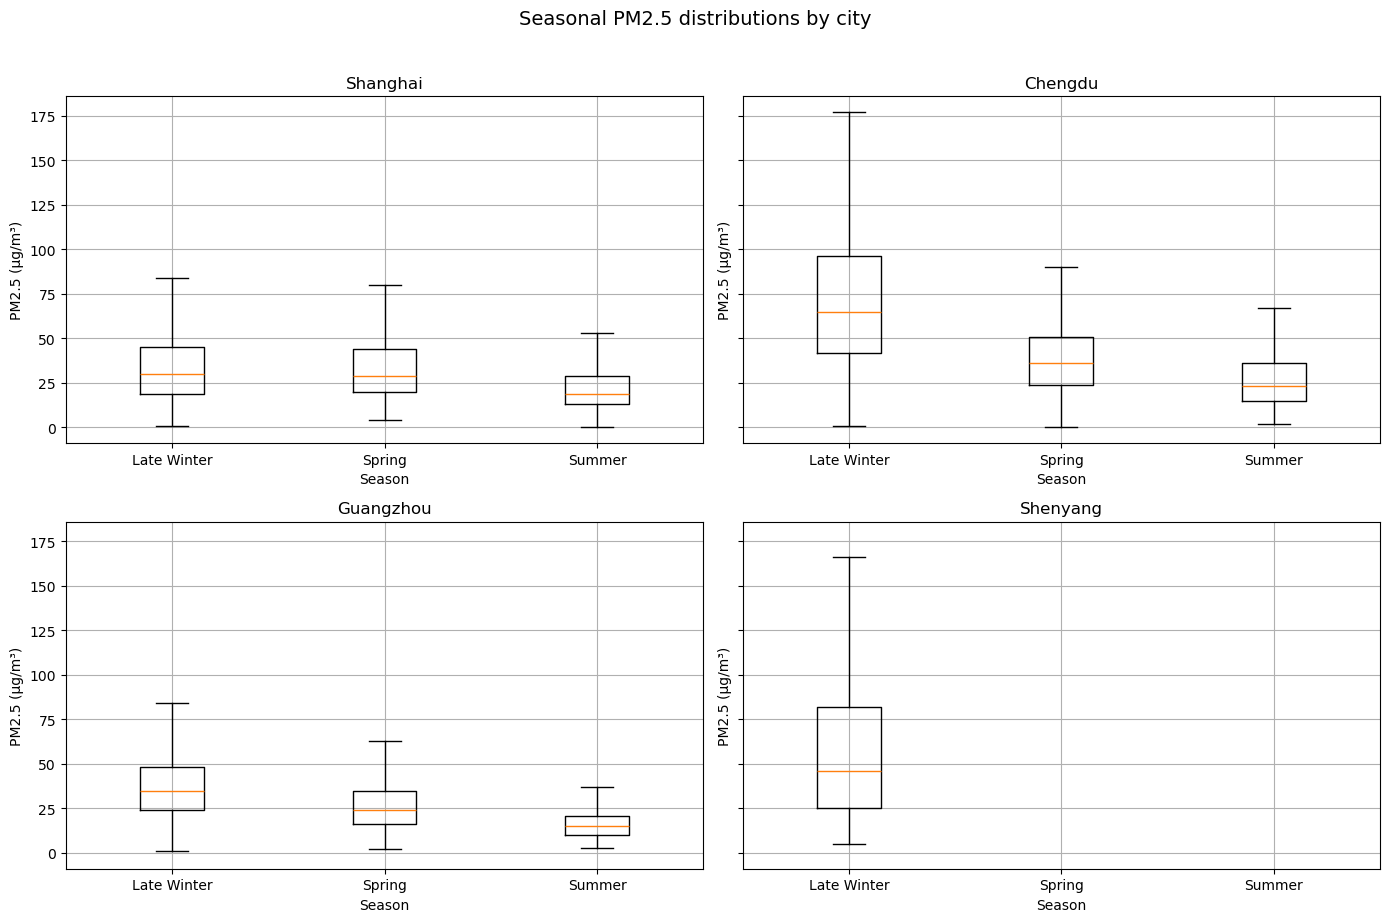

In [14]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 9), sharey=True)
axes = axes.ravel()
for ax, city in zip(axes, CITIES.keys()):
    data = [pm.loc[(pm["city"] == city) & (pm["season"] == s), "pm25"].dropna() for s in season_order]
    ax.boxplot(data, labels=season_order, showfliers=False)
    ax.set_title(city)
    ax.set_xlabel("Season")
    ax.set_ylabel("PM2.5 (µg/m³)")
fig.suptitle("Seasonal PM2.5 distributions by city", y=1.02, fontsize=14)
plt.tight_layout()

## 9. Diurnal patterns

To test Hypothesis 2, I compare hourly PM2.5 profiles across cities. I also compare commuting-related hours with midday hours.

### Figure 5. Mean PM2.5 by hour of day

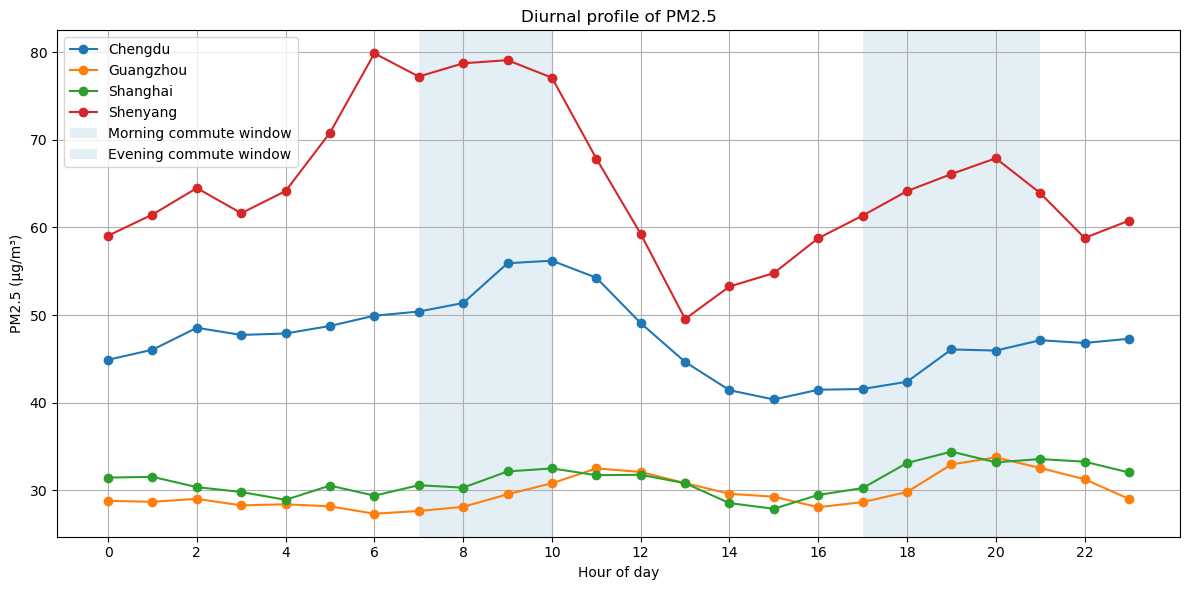

In [15]:
hourly_profile = (pm.groupby(["city", "hour"])["pm25"]
                    .agg(mean="mean", median="median", count="size")
                    .reset_index())

fig, ax = plt.subplots(figsize=(12, 6))
for city, sub in hourly_profile.groupby("city"):
    ax.plot(sub["hour"], sub["mean"], marker="o", label=city)
ax.axvspan(7, 10, alpha=0.12, label="Morning commute window")
ax.axvspan(17, 21, alpha=0.12, label="Evening commute window")
ax.set_title("Diurnal profile of PM2.5")
ax.set_xlabel("Hour of day")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_xticks(range(0, 24, 2))
ax.legend(loc="best")
plt.tight_layout()

### Figure 6. Seasonal diurnal profiles

This final figure combines the two temporal dimensions: season and hour of day. It helps show whether diurnal patterns are stable across the year or concentrated in specific seasons.

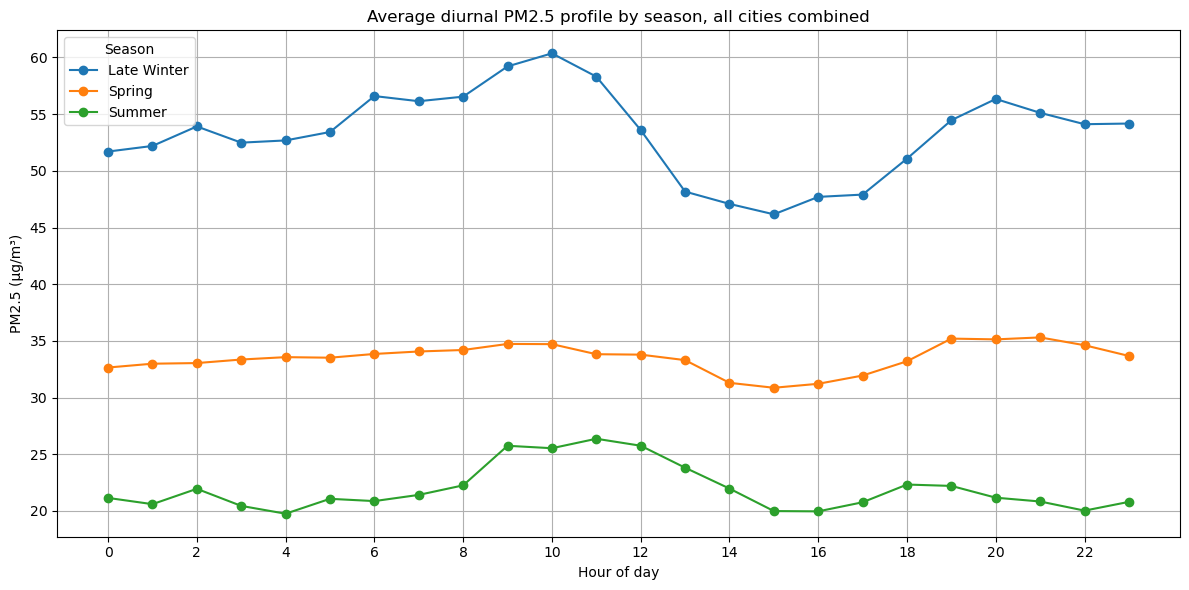

In [16]:
season_hour = (pm.groupby(["season", "hour"])["pm25"]
                 .mean()
                 .reset_index())

fig, ax = plt.subplots(figsize=(12, 6))
for season in season_order:
    sub = season_hour[season_hour["season"] == season]
    ax.plot(sub["hour"], sub["pm25"], marker="o", label=season)
ax.set_title("Average diurnal PM2.5 profile by season, all cities combined")
ax.set_xlabel("Hour of day")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_xticks(range(0, 24, 2))
ax.legend(title="Season")
plt.tight_layout()

## 10. Quantitative tests of the hypotheses

The plots above provide visual evidence. The tables below make the comparison explicit.

For Hypothesis 1, I calculate each city's late-winter mean, summer mean, and late-winter-minus-summer difference.
For Hypothesis 2, I compare commuting-window PM2.5 against midday PM2.5.

A note on the t-tests: hourly PM2.5 values are strongly autocorrelated within a day, so the p-values shown below are not valid independent-sample tests. I report them as a quick descriptive check on whether group means differ in the expected direction, not as formal significance tests.

In [17]:
seasonal_means = (pm.groupby(["city", "season"])["pm25"].mean()
                    .unstack("season")
                    .reindex(columns=season_order))
seasonal_means["winter_minus_summer"] = seasonal_means["Late Winter"] - seasonal_means["Summer"]
seasonal_means["winter_to_summer_ratio"] = seasonal_means["Late Winter"] / seasonal_means["Summer"]
seasonal_means.sort_values("winter_minus_summer", ascending=False)

season,Late Winter,Spring,Summer,winter_minus_summer,winter_to_summer_ratio
city,,,,,
Chengdu,71.863556,39.826630,27.942757,43.920799,2.571813
Guangzhou,43.925067,26.919289,16.188084,27.736983,2.713420
Shanghai,34.617908,33.945312,21.624396,12.993512,1.600873
Shenyang,65.071274,NaN,NaN,NaN,NaN


In [18]:
period_means = (pm[pm["day_period"].isin(["Morning commute", "Evening commute", "Midday"])]
                  .assign(commute=lambda d: d["day_period"].isin(["Morning commute", "Evening commute"]))
                  .groupby(["city", "commute"])["pm25"]
                  .mean()
                  .unstack("commute")
                  .rename(columns={False: "midday_mean", True: "commute_mean"}))
period_means["commute_minus_midday"] = period_means["commute_mean"] - period_means["midday_mean"]
period_means["commute_to_midday_ratio"] = period_means["commute_mean"] / period_means["midday_mean"]
period_means.sort_values("commute_minus_midday", ascending=False)

commute,midday_mean,commute_mean,commute_minus_midday,commute_to_midday_ratio
city,,,,
Shenyang,54.235294,70.836310,16.601015,1.306092
Chengdu,43.991304,48.779968,4.788664,1.108855
Shanghai,29.762590,32.210994,2.448404,1.082264
Guangzhou,30.481164,30.396032,-0.085133,0.997207


In [19]:
rows = []
for city in CITIES.keys():
    cdat = pm[pm["city"] == city]
    winter = cdat.loc[cdat["season"] == "Late Winter", "pm25"].dropna()
    summer = cdat.loc[cdat["season"] == "Summer", "pm25"].dropna()
    commute = cdat.loc[cdat["day_period"].isin(["Morning commute", "Evening commute"]), "pm25"].dropna()
    midday = cdat.loc[cdat["day_period"] == "Midday", "pm25"].dropna()
    if SCIPY_AVAILABLE:
        season_t = stats.ttest_ind(winter, summer, equal_var=False, nan_policy="omit")
        diurnal_t = stats.ttest_ind(commute, midday, equal_var=False, nan_policy="omit")
        season_p = season_t.pvalue
        diurnal_p = diurnal_t.pvalue
    else:
        season_p = np.nan
        diurnal_p = np.nan
    rows.append({
        "city": city,
        "winter_mean": winter.mean(),
        "summer_mean": summer.mean(),
        "winter_minus_summer": winter.mean() - summer.mean(),
        "season_p_value_descriptive": season_p,
        "commute_mean": commute.mean(),
        "midday_mean": midday.mean(),
        "commute_minus_midday": commute.mean() - midday.mean(),
        "diurnal_p_value_descriptive": diurnal_p,
    })

test_summary = pd.DataFrame(rows).sort_values("winter_minus_summer", ascending=False)
test_summary

,city,winter_mean,summer_mean,winter_minus_summer,season_p_value_descriptive,commute_mean,midday_mean,commute_minus_midday,diurnal_p_value_descriptive
1,Chengdu,71.863556,27.942757,43.920799,4.483234e-181,48.779968,43.991304,4.788664,0.003407
2,Guangzhou,43.925067,16.188084,27.736983,6.763652e-114,30.396032,30.481164,-0.085133,0.944049
0,Shanghai,34.617908,21.624396,12.993512,4.296274e-64,32.210994,29.762590,2.448404,0.005840
3,Shenyang,65.071274,NaN,NaN,NaN,70.836310,54.235294,16.601015,0.002119


## 11. Interpretation

Pulling together the figures and tables above, here's what I see for January 1 to August 9, 2021. All numbers are hourly station observations from OpenAQ.

**Overall pollution levels.** Across the January-August 2021 window, mean PM2.5 was Shenyang 65.1 ug/m3, then Chengdu 47.5, Shanghai 31.1, and Guangzhou 29.8. For comparison, the WHO 2021 annual PM2.5 guideline is 5 ug/m3 and China's national annual standard is 35 ug/m3. All four cities sat above the WHO number; Shenyang and Chengdu were also above the China number, and Shanghai and Guangzhou just below it. I'm being careful with words here: these aren't formal exceedances of an annual standard, because my data don't cover a full year. They're just useful magnitude checks. One thing to note about Shenyang: its number comes from only 926 hours of data, vs about 3,400 hours for each of the other cities, so I treat it as a hint, not as a direct comparison.

**The seasonal drop from late winter to summer.** For the three cities with full coverage, the late-winter mean is far above the summer mean. Chengdu shows the biggest absolute drop, going from 71.9 in Late Winter down to 27.9 in Summer (a difference of +44.0 ug/m3, ratio 2.6x). Guangzhou drops from 43.9 to 16.2, which is a smaller absolute change (+27.7) but actually the largest relative ratio at 2.7x. Shanghai is the flattest of the three, going from 34.6 down to 21.6 (+13.0, ratio 1.6x). Shenyang's Late Winter mean is 65.1 ug/m3, which fits the picture of strong northern heating-season pollution, but I can't compute a transition statistic for it because there are no spring or summer values inside this study window.

**What this says about Hypothesis 1.** The data hold up H1 in part, but with an important asymmetry: I can only directly test the seasonal-transition prediction for three of the four cities (Chengdu, Guangzhou, Shanghai), since Shenyang lacks spring and summer coverage in this study window. Among the testable three, the inland-basin city Chengdu shows the strongest absolute seasonal-transition signal, and the eastern coastal city Shanghai shows the weakest, both as I expected. But Guangzhou is a problem for the simple 'coastal cities are flatter' reading: it is the southernmost and most coastal city in this set, yet its relative drop is actually the largest. I think southern China's seasonal cycle isn't only about coastal ventilation, regional dry-season transport during winter (from inland China and Southeast Asia) may pull Guangzhou's winter values up more than its geography alone would suggest.

**The diurnal/commute pattern.** Hypothesis 2 gets mixed support. Shenyang shows a clean morning-and-evening peak: commute-window mean 70.8 vs midday 54.2, a +16.6 ug/m3 gap (1.31x). Chengdu and Shanghai show small positive differences in the same direction (+4.8 and +2.4 respectively). Guangzhou shows essentially no diurnal contrast at all (-0.1 ug/m3, ratio 1.00). Looking at Figure 6 (diurnal by season), the commuting peak is clearest in cold-season conditions and almost disappears in summer. This is consistent with a shallower nocturnal and early-morning boundary layer in winter amplifying any traffic-related signal.

**Bottom line on the two hypotheses.** H1 holds up with caveats: Chengdu vs Shanghai matches expectation, but Guangzhou complicates the simple north/inland vs south/coastal story. H2 holds up unevenly: Shenyang has a clear commute double-peak, Chengdu and Shanghai show muted versions, and Guangzhou shows no commute signal in this window.

In [20]:
annual_summary = (pm.groupby("city")["pm25"]
                    .agg(annual_mean="mean", annual_median="median", p90=lambda x: x.quantile(0.90), n="size")
                    .sort_values("annual_mean", ascending=False))
annual_summary

,annual_mean,annual_median,p90,n
city,,,,
Shenyang,65.071274,46.0,140.5,926
Chengdu,47.462434,39.0,93.0,3434
Shanghai,31.138228,26.0,57.0,3364
Guangzhou,29.791509,24.0,51.2,3439


## 12. Conclusion

This project used hourly OpenAQ station observations to compare seasonal-transition strengths and diurnal pollution patterns across four major Chinese cities (Shanghai, Chengdu, Guangzhou, Shenyang) for January 1 - August 9, 2021. The pipeline was: month-by-month API access, Pandas cleaning, period and hour-of-day grouping, then hypothesis-targeted plots and t-tests.

**Main findings:**

- All four cities' January-August 2021 mean PM2.5 levels are above the WHO 2021 annual guideline of 5 ug/m3. Shenyang (65.1) and Chengdu (47.5) are also above China's national annual standard of 35 ug/m3; Shanghai (31.1) and Guangzhou (29.8) are just below. These cannot be interpreted as formal annual-standard exceedances because the study window does not cover a full calendar year.
- The largest late-winter-to-summer drop is in Chengdu (+44.0 ug/m3, 2.6x), then Guangzhou (+27.7, 2.7x ratio), with Shanghai the smallest (+13.0, 1.6x). H1 is supported in part: the inland Chengdu vs coastal Shanghai contrast lines up with the expectation, but Guangzhou's large drop pushes back against a clean coastal-vs-inland story and points to regional dry-season transport in southern China.
- A clear morning + evening commuting peak relative to midday shows up in Shenyang (+16.6, 1.31x), is weaker in Chengdu and Shanghai (+4.8, +2.4), and is absent in Guangzhou (-0.1, ratio 1.00). H2 holds up only weakly. Figure 6 also suggests the commuting signal is amplified in cold-season conditions, presumably because the early-morning boundary layer is shallower then.

**Limitations:**

- The study window is January 1 - August 9, 2021, because OpenAQ's upstream Chinese provider stopped pushing real-time data in early August. So I don't have autumn or full mid-winter (Nov-Dec) coverage.
- Shenyang's sensor only reported during late winter inside this window (n = 926 hours, mostly Jan-Feb), so its summer mean and seasonal-transition statistics couldn't be computed. Any comparison involving Shenyang is necessarily one-sided.
- Hourly observations are strongly autocorrelated, so the t-tests in Section 10 should be read as descriptive group-mean comparisons, not formal causal tests.
- Each city is represented by the OpenAQ station nearest the city center. I'm not resolving intra-urban heterogeneity (industrial vs residential vs suburban).
- This analysis describes temporal patterns; it doesn't attribute causes. PM2.5 reflects emissions, meteorology, secondary aerosol formation, and long-range transport, none of which I separate here.

**What I'd do next:**

- Combine PM2.5 with co-located meteorological data (boundary-layer height, wind speed, precipitation, temperature inversions) to split the seasonal and diurnal signals into emission-driven vs ventilation-driven components.
- Use a longer multi-year window from a still-active data source (e.g., U.S. embassy AirNow stations, or earlier OpenAQ years) so the same hypotheses can be tested with full annual cycles.
- Add a fifth, truly northern city with continuous full-year coverage so H1 can be tested cleanly without the Shenyang gap.